Define Basic Parameter

In [5]:
import requests
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import matplotlib.pyplot as plt
import json

Please generate api key  and enter into code cell

In [ ]:
# Enter the latitude and longitude for the location you want to query.
# The script will use these coordinates to fetch the corresponding Micro-Watershed (MWS) ID,
# and then retrieve the data associated with that specific microwatershed.
25.152227367955156, 75.10907576894641
latitude = "25.152227367955156"
longitude  = " 75.10907576894641"
# latitude = "12.971599"
# longitude = "77.594566"


#  Base URL for the CoreStack  API end point
base_url = 'https://geoserver.core-stack.org/api/v1/'

# Endpoint to retrieve the Micro-Watershed (MWS) ID using latitude and longitude
lat_long_mws_api_endpoint = 'get_mwsid_by_latlon/'

# Endpoint to retrieve detailed data for a given Micro-Watershed (MWS) ID
mws_data_api_endpoint = 'get_tehsil_data/'

# Add your API key here.
# You can generate an API key by logging into https://dashboard.core-stack.org with an Organization Admin account.
# Only Org Admins have permission to generate API keys.
# If you are not an Org Admin, please contact your admin to obtain access.
Api_key = ''

In [7]:
# Define the HTTP request headers with the API key
headers = {
    "X-API-Key": Api_key
}

# Define the query parameters to be sent in the API request

params = {
    "latitude": latitude,
    "longitude": longitude
}

# Construct the full API URL by combining base URL and endpoint
mws_lat_long_api_url = f"{base_url}{lat_long_mws_api_endpoint}"


# Make the GET request with headers and parameters
response = requests.get(mws_lat_long_api_url, params=params, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse JSON response data
    response_data_mws_lat_long = response.json()
    print(response.json())
    # You can now work with 'response_data_mws_lat_long'
    print("API call successful. Data received.")
else:
    # Handle errors - print status code and response text for debugging
    print(f"API call failed with status code: {response.status_code}")
    print("Response content:", response.text)
    # Optional: you can raise an exception or handle retries here





{'State': 'RAJASTHAN', 'District': 'BHILWARA', 'Tehsil': 'MANDALGARH', 'mws_id': '12_106205'}
API call successful. Data received.


In [10]:
def build_query_params_from_lat_long_api(mws_lat_long_response):
    """
    Extracts relevant query parameters from the MWS lat-long API response
    and returns them in a dictionary format suitable for further API calls.

    Args:
        mws_lat_long_response (dict): Response JSON from the lat-long API containing location info.

    Returns:
        dict: A dictionary with keys 'state', 'district', 'tehsil', and 'mws_id'.
    """
    d = {}
    print(mws_lat_long_response)
    # Extract state name from the API response
    d['state'] = mws_lat_long_response['State']

    # Extract district name from the API response
    d['district'] = mws_lat_long_response['District']

    # Extract tehsil (sub-district) name from the API response
    d['tehsil'] = mws_lat_long_response['Tehsil']

    # Extract unique MWS identifier
    d['mws_id'] = mws_lat_long_response['mws_id']

    return d


In [11]:
# Build query parameters from the previous API response
param2 = build_query_params_from_lat_long_api(response_data_mws_lat_long)
print (param2)

# Construct the full URL for the MWS data API endpoint
mws_data_url = f"{base_url}{mws_data_api_endpoint}"

# Make the GET request with the constructed parameters and headers

response = requests.get(mws_data_url, params=param2, headers=headers)
print(response.json())
drought_record = response.json()['drought_causality'][0]
data = response.json()
ci_record  = response.json()['croppingIntensity_annual'][0]
print(ci_record)
# Check if the request was successful


{'State': 'RAJASTHAN', 'District': 'BHILWARA', 'Tehsil': 'MANDALGARH', 'mws_id': '12_106205'}
{'state': 'RAJASTHAN', 'district': 'BHILWARA', 'tehsil': 'MANDALGARH', 'mws_id': '12_106205'}
{'aquifer_vector': [{'uid': '12_100174', 'area_in_ha': 3182.47, 'aquifer_class': 'Hard Rock', 'principle_aq_alluvium_percent': 0.0, 'principle_aq_banded gneissic complex_percent': 0.0, 'principle_aq_basalt_percent': 0, 'principle_aq_charnockite_percent': 0, 'principle_aq_gneiss_percent': 24.65, 'principle_aq_granite_percent': 0.0, 'principle_aq_intrusive_percent': 21.95, 'principle_aq_khondalite_percent': 0, 'principle_aq_laterite_percent': 0, 'principle_aq_limestone_percent': 0, 'principle_aq_none_percent': 11.0, 'principle_aq_quartzite_percent': 14.7, 'principle_aq_sandstone_percent': 0, 'principle_aq_schist_percent': 0.0, 'principle_aq_shale_percent': 27.7}, {'uid': '12_101214', 'area_in_ha': 752.09, 'aquifer_class': 'Hard Rock', 'principle_aq_alluvium_percent': 0.0, 'principle_aq_banded gneissic c

In [14]:
def analyze_mws_drought_impact(drought_record, ci_record):

    # Normalize in case API returns list
    if isinstance(drought_record, list):
        if not drought_record:
            return None
        drought_record = drought_record[0]

    if isinstance(ci_record, list):
        if not ci_record:
            return None
        ci_record = ci_record[0]

    # -----------------------------
    # Identify drought years
    # -----------------------------
    drought_years = set()

    for key, val in drought_record.items():
        if key.startswith("severe_moderate_drought_causality"):
            try:
                year = int(key[-4:])
            except ValueError:
                continue

            try:
                drivers = json.loads(val) if val else {}
            except json.JSONDecodeError:
                drivers = {}

            if drivers and any(float(v or 0) > 0 for v in drivers.values()):
                drought_years.add(year)

    drought_years = sorted(drought_years)

    # -----------------------------
    # Extract Cropping Intensity
    # -----------------------------
    ci = {}

    for key, val in ci_record.items():
        if key.startswith("cropping_intensity_unit_less"):
            match = re.search(r"(\d{4})", key)
            if match:
                try:
                    ci[int(match.group(1))] = float(val)
                except (ValueError, TypeError):
                    pass

    # -----------------------------
    # Baseline CI (non-drought years)
    # -----------------------------
    non_drought_years = [y for y in ci if y not in drought_years]

    baseline_ci = None
    if len(non_drought_years) >= 2:
        baseline_ci = sum(ci[y] for y in non_drought_years) / len(non_drought_years)
    elif len(ci) >= 3:
        baseline_ci = statistics.median(ci.values())

    # -----------------------------
    # CI deviation during drought
    # -----------------------------
    ci_difference = {}

    if baseline_ci is not None:
        for y in drought_years:
            if y in ci:
                ci_difference[y] = ci[y] - baseline_ci

    return {
        "mws_id": drought_record.get("uid"),
        "ci": ci,
        "baseline_ci": baseline_ci,
        "drought_years": drought_years,
        "ci_difference": ci_difference
    }


In [15]:
import re
import statistics
all_mws_outputs = []
drought_list = data["drought_causality"]
ci_list = data["croppingIntensity_annual"]

    # Join by index (or uid if needed)
for d_rec, ci_rec in zip(drought_list, ci_list):
        result = analyze_mws_drought_impact(d_rec, ci_rec)
        if result:
            all_mws_outputs.append(result)

print(f"Total MWS processed: {len(all_mws_outputs)}")

Total MWS processed: 101


In [16]:
ranking = []

for mws in all_mws_outputs:
    ci_diff = mws["ci_difference"]

    if not ci_diff:
        continue

    worst_year, worst_drop = min(ci_diff.items(), key=lambda x: x[1])

    ranking.append({
        "mws_id": mws["mws_id"],
        "worst_drought_year": worst_year,
        "observed_ci_drop": abs(worst_drop)
    })

ranking = sorted(ranking, key=lambda x: x["observed_ci_drop"], reverse=True)

print("\nTOP 5 MWS BY OBSERVED DROUGHT IMPACT\n")
for i, r in enumerate(ranking[:5], start=1):
    print(
        f"{i}. MWS: {r['mws_id']} | "
        f"CI Drop: {r['observed_ci_drop']:.3f} | "
        f"Worst Year: {r['worst_drought_year']}"
    )
top5_mws = ranking[:5]
print(top5_mws)


TOP 5 MWS BY OBSERVED DROUGHT IMPACT

1. MWS: 12_107714 | CI Drop: 0.530 | Worst Year: 2017
2. MWS: 12_107882 | CI Drop: 0.475 | Worst Year: 2017
3. MWS: 12_107515 | CI Drop: 0.423 | Worst Year: 2017
4. MWS: 12_107276 | CI Drop: 0.417 | Worst Year: 2017
5. MWS: 12_106207 | CI Drop: 0.370 | Worst Year: 2017
[{'mws_id': '12_107714', 'worst_drought_year': 2017, 'observed_ci_drop': 0.53}, {'mws_id': '12_107882', 'worst_drought_year': 2017, 'observed_ci_drop': 0.47499999999999987}, {'mws_id': '12_107515', 'worst_drought_year': 2017, 'observed_ci_drop': 0.4233333333333331}, {'mws_id': '12_107276', 'worst_drought_year': 2017, 'observed_ci_drop': 0.41749999999999987}, {'mws_id': '12_106207', 'worst_drought_year': 2017, 'observed_ci_drop': 0.3699999999999999}]


In [17]:
import json
village_lookup = {
    v["village_id"]: v["village_name"]
    for v in data.get("social_economic_indicator", [])
}
print (village_lookup)


{95845: 'Barla', 96083: 'Chandpura', 96084: 'Ampura', 96085: 'Ummedpura', 96086: 'Katariyon Ka Khera', 96087: 'Rajgarh', 96088: 'Khakhunda', 96089: 'Peethalpura', 96090: 'Bagthala', 96091: 'Gothra', 96092: 'Laxmipura', 96093: 'Thalkhurd', 96094: 'Jaal Ka Khera', 96095: 'Thal Kalan', 96096: 'Harisinghji Ka Khera@Nathawaton Ka Khera', 96097: 'Beeliya', 96098: 'Hindusinghji Ka Khera@ Chhur Ka Koh', 96099: 'Meetha', 96100: 'Dhamniya', 96101: 'Nahargarh', 96102: 'Jagpura', 96103: 'Harpura', 96104: 'Latala', 96105: 'Kachhola', 96106: 'Lachhmangarh', 96107: 'Samthala', 96108: 'Sarthala', 96109: 'Madhu Puriya', 96110: 'Rajpura', 96111: 'Keeratpura', 96112: 'Hindusinghji Ki Garhi', 96113: 'Deopuriya', 96114: 'Harjaspura', 96115: 'Keriya', 96116: 'Bakhatpura', 96117: 'Salampura', 96118: 'Chawandiya', 96119: 'Amli', 96120: 'Jassu Ji Ka Khera', 96121: 'Nathji Ka Khera', 96122: 'Mala Ka Khera', 96123: 'Achala Ji Ka Khera', 96124: 'Bharji Ka Khera', 96125: 'Jhanjhola', 96126: 'Rooparel', 96127: 'Sha

In [18]:
mws_to_village_ids = {}

for rec in data.get("mws_intersect_villages", []):
    mws_uid = rec.get("mws uid")

    try:
        village_ids = json.loads(rec.get("village ids", "[]"))
    except json.JSONDecodeError:
        village_ids = []

    mws_to_village_ids[mws_uid] = village_ids
print (mws_to_village_ids)

{'12_82699': [96247], '12_108057': [96248, 96249], '12_107514': [96248, 96247], '12_108208': [96264, 96249, 96265], '12_82338': [96244, 96245], '12_107713': [96215, 96248, 96247, 96216, 96246, 96249], '12_65523': [96256, 96257, 96173, 96174], '12_104550': [96249], '12_108325': [96257, 96258, 96259, 96260, 96261, 96268, 96252, 96253, 96254, 96255], '12_101654': [96259, 96260, 96261, 96262, 96267, 96268, 96252], '12_96317': [96256, 96257, 96258, 96164, 96167, 96168, 96175, 96176, 96177, 96178, 96180], '12_99859': [96233, 96131], '12_65390': [96257, 96173], '12_99608': [96256, 96258, 96259, 96253, 96254, 96255], '12_65147': [96169, 96170, 96171, 96172, 96173], '12_106388': [96264, 248814, 96248, 96216, 96249, 96250, 96251], '12_101307': [96261, 96262, 96250, 96251, 96252], '12_65269': [96256, 96168, 96169, 96170, 96173, 96174, 96175, 96176], '12_98488': [96256, 96257, 96258, 96175, 96176, 96178, 96179, 96183, 96185, 96254, 96255], '12_53417': [96164, 96165, 96180, 96182, 96188, 96189], '1

In [20]:
top_5_mws_with_villages = []

for mws in top5_mws:
    mws_uid = mws["mws_id"]

    village_ids = mws_to_village_ids.get(mws_uid, [])

    villages = [
        {
            "village_id": vid,
            "village_name": village_lookup.get(vid, "UNKNOWN")
        }
        for vid in village_ids
    ]

    top_5_mws_with_villages.append({
        "mws_id": mws_uid,
        "worst_drought_year": mws["worst_drought_year"],
        "observed_ci_drop": mws["observed_ci_drop"],
        "villages": villages
    })
print(top_5_mws_with_villages)

[{'mws_id': '12_107714', 'worst_drought_year': 2017, 'observed_ci_drop': 0.53, 'villages': [{'village_id': 96105, 'village_name': 'Kachhola'}, {'village_id': 96084, 'village_name': 'Ampura'}, {'village_id': 96087, 'village_name': 'Rajgarh'}, {'village_id': 96088, 'village_name': 'Khakhunda'}, {'village_id': 96089, 'village_name': 'Peethalpura'}, {'village_id': 96090, 'village_name': 'Bagthala'}, {'village_id': 96091, 'village_name': 'Gothra'}]}, {'mws_id': '12_107882', 'worst_drought_year': 2017, 'observed_ci_drop': 0.47499999999999987, 'villages': [{'village_id': 96105, 'village_name': 'Kachhola'}, {'village_id': 96088, 'village_name': 'Khakhunda'}, {'village_id': 96090, 'village_name': 'Bagthala'}, {'village_id': 96091, 'village_name': 'Gothra'}, {'village_id': 96092, 'village_name': 'Laxmipura'}, {'village_id': 96093, 'village_name': 'Thalkhurd'}, {'village_id': 96094, 'village_name': 'Jaal Ka Khera'}, {'village_id': 96095, 'village_name': 'Thal Kalan'}]}, {'mws_id': '12_107515', 'w

In [21]:
for rec in top_5_mws_with_villages:
    print(f"\nMWS ID: {rec['mws_id']}")
    print(f"  Worst drought year: {rec['worst_drought_year']}")
    print(f"  Observed CI drop: {rec['observed_ci_drop']:.3f}")

    if not rec["villages"]:
        print("  No villages mapped")
    else:
        for v in rec["villages"]:
            print(f"  - {v['village_id']} : {v['village_name']}")



MWS ID: 12_107714
  Worst drought year: 2017
  Observed CI drop: 0.530
  - 96105 : Kachhola
  - 96084 : Ampura
  - 96087 : Rajgarh
  - 96088 : Khakhunda
  - 96089 : Peethalpura
  - 96090 : Bagthala
  - 96091 : Gothra

MWS ID: 12_107882
  Worst drought year: 2017
  Observed CI drop: 0.475
  - 96105 : Kachhola
  - 96088 : Khakhunda
  - 96090 : Bagthala
  - 96091 : Gothra
  - 96092 : Laxmipura
  - 96093 : Thalkhurd
  - 96094 : Jaal Ka Khera
  - 96095 : Thal Kalan

MWS ID: 12_107515
  Worst drought year: 2017
  Observed CI drop: 0.423
  - 96088 : Khakhunda
  - 96089 : Peethalpura
  - 96090 : Bagthala
  - 96091 : Gothra
  - 96092 : Laxmipura
  - 96093 : Thalkhurd
  - 96095 : Thal Kalan

MWS ID: 12_107276
  Worst drought year: 2017
  Observed CI drop: 0.417
  - 96097 : Beeliya
  - 96098 : Hindusinghji Ka Khera@ Chhur Ka Koh
  - 96099 : Meetha
  - 96100 : Dhamniya
  - 96139 : Sangrampura
  - 96095 : Thal Kalan

MWS ID: 12_106207
  Worst drought year: 2017
  Observed CI drop: 0.370
  - 96100 

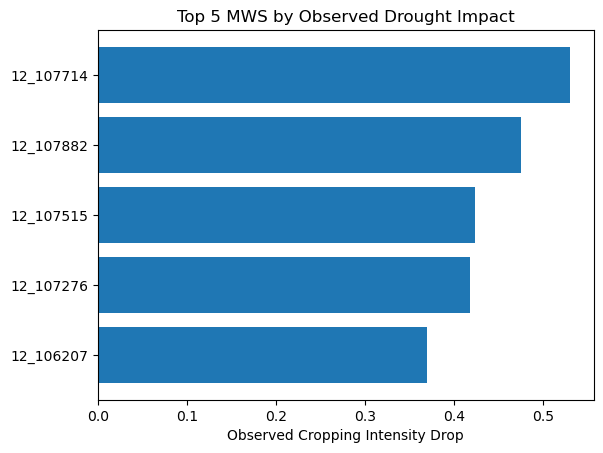

In [22]:
labels = [r["mws_id"] for r in ranking[:5]]
drops = [r["observed_ci_drop"] for r in ranking[:5]]

plt.figure()
plt.barh(labels, drops)
plt.xlabel("Observed Cropping Intensity Drop")
plt.title("Top 5 MWS by Observed Drought Impact")
plt.gca().invert_yaxis()
plt.show()
